#   Lab     :   Working with different file formats
##  Executor:   LiR
### Date    :   30-12-2025

#### - Data Engineering
#### - Data Engineering Process
#### - Working with different file formats
#### - Data Analysis

#### Кратко

    - ✔ import pandas as pd без ошибки → pandas установлен
    - ✔ pd.__version__ → точное подтверждение
    - ✔ import lxml → проверка парсера
    - ✔ sys.executable → какое окружение реально используется

In [8]:
# в каком окружении  сейчас работаешь
import sys
print(sys.platform)
print(sys.executable)


win32
c:\dev_soft\anaconda3_2023\python.exe


In [3]:
import pandas as pd
print(pd.__version__)
import lxml
print(lxml.__version__)

2.3.3
5.3.0


In [4]:
import importlib.util

def is_installed(pkg):
    return importlib.util.find_spec(pkg) is not None

print(is_installed("pandas"))
print(is_installed("lxml"))
print(is_installed("openpyxl"))
print(is_installed("seaborn"))


True
True
True
True


In [6]:
import pandas as pd
pd.read_html

<function pandas.io.html.read_html(io: 'FilePath | ReadBuffer[str]', *, match: 'str | Pattern' = '.+', flavor: 'HTMLFlavors | Sequence[HTMLFlavors] | None' = None, header: 'int | Sequence[int] | None' = None, index_col: 'int | Sequence[int] | None' = None, skiprows: 'int | Sequence[int] | slice | None' = None, attrs: 'dict[str, str] | None' = None, parse_dates: 'bool' = False, thousands: 'str | None' = ',', encoding: 'str | None' = None, decimal: 'str' = '.', converters: 'dict | None' = None, na_values: 'Iterable[object] | None' = None, keep_default_na: 'bool' = True, displayed_only: 'bool' = True, extract_links: "Literal[None, 'header', 'footer', 'body', 'all']" = None, dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>, storage_options: 'StorageOptions' = None) -> 'list[DataFrame]'>

In [ ]:
# in Anaconda Prompt
# conda install seaborn lxml openpyxl
# or 
# pip install seaborn lxml openpyxl


In [ ]:
#In Jupyter
import sys
!{sys.executable} -m pip install seaborn lxml openpyxl

Defaulting to user installation because normal site-packages is not writeable


### Install  via Coursera Platform  (Pyodide / WebAssembly)

In [ ]:

#await piplite.install(['seaborn', 'lxml', 'openpyxl'])
#import pandas as pd

In [ ]:
#filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/addresses.csv"#

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

#await download(filename, "addresses.csv")

#df = pd.read_csv("addresses.csv", header=None)

In [16]:
#Comma-separated values (CSV) file format
#from pyodide.http import pyfetch
import requests
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/addresses.csv"
local_file = "addresses.csv"

response = requests.get(url)

if response.status_code == 200:
    with open(local_file, "wb") as f:
        f.write(response.content)
else:
    raise Exception(f"Download failed: {response.status_code}")

df = pd.read_csv(local_file, header=None)
print(df.head())


               0         1                                 2          3    4  \
0           John       Doe                 120 jefferson st.  Riverside   NJ   
1           Jack  McGinnis                      220 hobo Av.      Phila   PA   
2  John "Da Man"    Repici                 120 Jefferson St.  Riverside   NJ   
3        Stephen     Tyler  7452 Terrace "At the Plaza" road   SomeTown   SD   
4            NaN  Blankman                               NaN   SomeTown   SD   

       5  
0   8075  
1   9119  
2   8075  
3  91234  
4    298  


In [20]:
#Adding column name to the DataFrame
#We can add columns to an existing DataFrame using its columns attribute.
df.columns =['First Name', 'Last Name', 'Location ', 'City','State','Area Code']
df

,First Name,Last Name,Location,City,State,Area Code
0,John,Doe,120 jefferson st.,Riverside,NJ,8075
1,Jack,McGinnis,220 hobo Av.,Phila,PA,9119
2,"John ""Da Man""",Repici,120 Jefferson St.,Riverside,NJ,8075
3,Stephen,Tyler,"7452 Terrace ""At the Plaza"" road",SomeTown,SD,91234
4,NaN,Blankman,NaN,SomeTown,SD,298
5,"Joan ""the bone"", Anne",Jet,"9th, at Terrace plc",Desert City,CO,123


In [29]:
#Selecting a single column
#To select the first column 'First Name', you can pass the column name as a string to the indexing operator.
df["First Name"]


0                     John
1                     Jack
2            John "Da Man"
3                  Stephen
4                      NaN
5    Joan "the bone", Anne
Name: First Name, dtype: object

In [30]:
#To select multiple columns, you can pass a list of column names to the indexing operator.
df = df[['First Name', 'Last Name', 'Location ', 'City','State','Area Code']]
df


,First Name,Last Name,Location,City,State,Area Code
0,John,Doe,120 jefferson st.,Riverside,NJ,8075
1,Jack,McGinnis,220 hobo Av.,Phila,PA,9119
2,"John ""Da Man""",Repici,120 Jefferson St.,Riverside,NJ,8075
3,Stephen,Tyler,"7452 Terrace ""At the Plaza"" road",SomeTown,SD,91234
4,NaN,Blankman,NaN,SomeTown,SD,298
5,"Joan ""the bone"", Anne",Jet,"9th, at Terrace plc",Desert City,CO,123


In [31]:
#loc() : loc() is label based data selecting method which means that we have to pass the name of the row or column which we want to select.
# To select the first row
df.loc[0]

First Name                 John
Last Name                   Doe
Location      120 jefferson st.
City                  Riverside
State                        NJ
Area Code                  8075
Name: 0, dtype: object

In [32]:
# To select the 0th,1st and 2nd row of "First Name" column only
df.loc[[0,1,2], "First Name" ]

0             John
1             Jack
2    John "Da Man"
Name: First Name, dtype: object

In [33]:
#iloc() : iloc() is a indexed based selecting method which means that we have to pass integer index in the method to select specific row/column.
# To select the 0th,1st and 2nd row of "First Name" column only
df.iloc[[0,1,2], 0]

0             John
1             Jack
2    John "Da Man"
Name: First Name, dtype: object

### Transform Function in Pandas

In [35]:
#import library
import pandas as pd
import numpy as np

In [40]:
#creating a dataframe
# rows - index
#df=pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]), columns=['a', 'b', 'c'], index=['a', 'b', 'c'])

df=pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]), columns=['a', 'b', 'c'])
df

,a,b,c
0,1,2,3
1,4,5,6
2,7,8,9


In [41]:
#Let’s say we want to add 10 to each element in a dataframe:
#applying the transform function
df = df.transform(func = lambda x : x + 10)
df


,a,b,c
0,11,12,13
1,14,15,16
2,17,18,19


In [45]:
#Now we will use DataFrame.transform() function to find the square root to each element of the dataframe.
result = df.transform(func = ['sqrt'])

result

,a,b,c
,sqrt,sqrt,sqrt
0,3.316625,3.464102,3.605551
1,3.741657,3.872983,4.000000
2,4.123106,4.242641,4.358899


####    JSON file FormaT
######  JSON (JavaScript Object Notation) is a lightweight data-interchange format. It is easy for humans to read and write.

In [46]:
import json

In [48]:
#Writing JSON to a File
import json
person = {
    'first_name' : 'Mark',
    'last_name' : 'abc',
    'age' : 27,
    'address': {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}
person

{'first_name': 'Mark',
 'last_name': 'abc',
 'age': 27,
 'address': {'streetAddress': '21 2nd Street',
  'city': 'New York',
  'state': 'NY',
  'postalCode': '10021-3100'}}

#####   serialization using dump() function
###### json.dump() method can be used for writing to JSON file.

###### Syntax: json.dump(dict, file_pointer)

##### Parameters:

###### dictionary – name of the dictionary which should be converted to JSON object.
###### file pointer – pointer of the file opened in write or append mode.

In [ ]:
# write запись to File person.json
with open('person.json', 'w') as f:  # writing JSON object
    json.dump(person, f)


#####   serialization using dumps() function
#####   json.dumps() that helps in converting a dictionary to a JSON object.

#####   It takes two parameters:

######  dictionary – name of the dictionary which should be converted to JSON object.
######   indent – defines the number of units for indentation

In [59]:
# Serializing json  
print(person)
json_object = json.dumps(person, indent = 4) 
  
# Writing to sample.json 
with open("sample.json", "w") as outfile: 
    outfile.write(json_object) 
print(json_object)

{'first_name': 'Mark', 'last_name': 'abc', 'age': 27, 'address': {'streetAddress': '21 2nd Street', 'city': 'New York', 'state': 'NY', 'postalCode': '10021-3100'}}
{
    "first_name": "Mark",
    "last_name": "abc",
    "age": 27,
    "address": {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}


##### Reading JSON to a File

In [60]:
#Using json.load()
import json 
  
# Opening JSON file 
with open('sample.json', 'r') as openfile: 
  
    # Reading from json file 
    json_object = json.load(openfile) 
  
print(json_object) 
print(type(json_object)) 

{'first_name': 'Mark', 'last_name': 'abc', 'age': 27, 'address': {'streetAddress': '21 2nd Street', 'city': 'New York', 'state': 'NY', 'postalCode': '10021-3100'}}
<class 'dict'>


##### XLSX file format
######   XLSX is a Microsoft Excel Open XML file format. It is another type of Spreadsheet file format.

######  In XLSX data is organized under the cells and columns in a sheet.

In [66]:
#Reading the data from XLSX file
import requests
import pandas as pd
# Not needed unless you're running locally
# import urllib.request
# urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/file_example_XLSX_10.xlsx", "sample.xlsx")

filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/file_example_XLSX_10.xlsx"

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

#await download(filename, "file_example_XLSX_10.xlsx")
local_file = "file_example_XLSX_10.xlsx"

response = requests.get(filename)

if response.status_code == 200:
    with open(local_file, "wb") as f:
        f.write(response.content)

df = pd.read_excel("file_example_XLSX_10.xlsx")
df

,0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468
5,6,Gaston,Brumm,Male,United States,24,21/05/2015,2554
6,7,Etta,Hurn,Female,Great Britain,56,15/10/2017,3598
7,8,Earlean,Melgar,Female,United States,27,16/08/2016,2456
8,9,Vincenza,Weiland,Female,United States,40,21/05/2015,6548


#####   XML file format
######  XML is also known as Extensible Markup Language. As the name suggests, it is a markup language. It has certain rules for encoding data. XML file format is a human-readable and machine-readable file format.
######  https://docs.python.org/3/library/xml.etree.elementtree.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkPY0101ENSkillsNetwork19487395-2021-01-01

In [67]:
#Writing with xml.etree.ElementTree
import xml.etree.ElementTree as ET

# create the file structure
employee = ET.Element('employee')
details = ET.SubElement(employee, 'details')
first = ET.SubElement(details, 'firstname')
second = ET.SubElement(details, 'lastname')
third = ET.SubElement(details, 'age')
first.text = 'Shiv'
second.text = 'Mishra'
third.text = '23'

# create a new XML file with the results
mydata1 = ET.ElementTree(employee)
# myfile = open("items2.xml", "wb")
# myfile.write(mydata)
with open("new_sample.xml", "wb") as files:
    mydata1.write(files)


In [71]:
#Reading with xml.etree.ElementTree
import requests
import pandas as pd

filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Sample-employee-XML-file.xml"
local_file = 'Sample-employee-XML-file.xml'

response = requests.get(filename)

if response.status_code == 200:
    with open(local_file, "wb") as f:
        f.write(response.content)

#----------------------------read_xml
df = pd.read_xml(local_file)
df

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


In [79]:
# Parse the XML file
import xml.etree.ElementTree as etree
tree = etree.parse("Sample-employee-XML-file.xml")

# Get the root of the XML tree
root = tree.getroot()

# Define the columns for the DataFrame
columns = ["firstname", "lastname", "title", "division", "building", "room"]

# Initialize an empty DataFrame
datatframe = pd.DataFrame(columns=columns)

# Iterate through each node in the XML root
for node in root:
    # Extract text from each element
    firstname = node.find("firstname").text
    lastname = node.find("lastname").text
    title = node.find("title").text
    division = node.find("division").text
    building = node.find("building").text
    room = node.find("room").text
    
    # Create a DataFrame for the current row
    row_df = pd.DataFrame([[firstname, lastname, title, division, building, room]], columns=columns)
    
    # Concatenate with the existing DataFrame
    datatframe = pd.concat([datatframe, row_df], ignore_index=True)

In [80]:
datatframe

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,02
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


In [81]:
#Reading xml file using pandas.read_xml function
# Herein xpath we mention the set of xml nodes to be considered for migrating  to the dataframe which in this case is details node under employees.
df = pd.read_xml("Sample-employee-XML-file.xml", xpath="/employees/details") 
df

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


In [83]:
#Save Data
datatframe.to_csv("employee.csv", index=False)
pd.read_csv("employee.csv")

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


<h2>Read/Save Other Data Formats</h2>

| Data Formate |        Read       |            Save |
| ------------ | :---------------: | --------------: |
| csv          |  `pd.read_csv()`  |   `df.to_csv()` |
| json         |  `pd.read_json()` |  `df.to_json()` |
| excel        | `pd.read_excel()` | `df.to_excel()` |
| hdf          |  `pd.read_hdf()`  |   `df.to_hdf()` |
| sql          |  `pd.read_sql()`  |   `df.to_sql()` |
![image.png](attachment:image.png)

####    Binary File Format
######  Binary files can range from image files like JPEGs or GIFs, audio files like MP3s or binary document formats like Word or PDF

In [86]:
#Reading the Image file
# importing PIL 
from PIL import Image 
import requests

# Uncomment if running locally
# import urllib.request
# urllib.request.urlretrieve("https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg", "dog.jpg")

filename = "https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"
local_file = 'dog.jpg'

response = requests.get(filename)

if response.status_code == 200:
    with open(local_file, "wb") as f:
        f.write(response.content)
# Read image 
img = Image.open('./dog.jpg','r') 
# Output Images 
img.show()


### Data Analysis

In [ ]:
#Content: The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.
#  We have 768 rows and 9 columns. The first 8 columns represent the features and the last column represent the target/label.
import pandas as pd
import requests
filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/diabetes.csv"?
local_file = 'diabetes.csv'

response = requests.get(filename)

if response.status_code == 200:
    with open(local_file, "wb") as f:
        f.write(response.content)
df = pd.read_csv(local_file)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [88]:
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [89]:
#To view the dimensions (size) of the dataframe, we use the .shape parameter.
df.shape

(768, 9)

In [90]:
#Statistical Overview of dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

In [94]:
#Identify and handle missing values
missing_data = df.isnull()
missing_data.head(5)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False


In [95]:
df.notnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...
763,True,True,True,True,True,True,True,True,True
764,True,True,True,True,True,True,True,True,True
765,True,True,True,True,True,True,True,True,True
766,True,True,True,True,True,True,True,True,True


In [96]:
#Count missing values in each column
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")  

Pregnancies
Pregnancies
False    768
Name: count, dtype: int64

Glucose
Glucose
False    768
Name: count, dtype: int64

BloodPressure
BloodPressure
False    768
Name: count, dtype: int64

SkinThickness
SkinThickness
False    768
Name: count, dtype: int64

Insulin
Insulin
False    768
Name: count, dtype: int64

BMI
BMI
False    768
Name: count, dtype: int64

DiabetesPedigreeFunction
DiabetesPedigreeFunction
False    768
Name: count, dtype: int64

Age
Age
False    768
Name: count, dtype: int64

Outcome
Outcome
False    768
Name: count, dtype: int64



In [97]:
#Correct data format
#.dtype() to check the data type
#.astype() to change the data type
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [98]:
#Visualization
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns

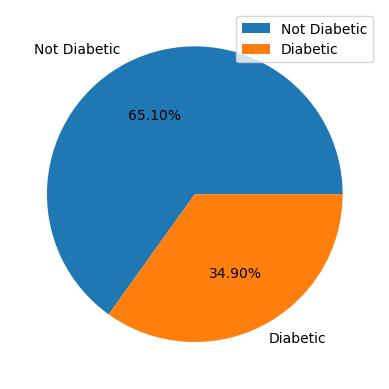

In [99]:
labels= 'Not Diabetic','Diabetic'
plt.pie(df['Outcome'].value_counts(),labels=labels,autopct='%0.02f%%')
plt.legend()
plt.show()